In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_file = 'customer_churn_data_raw.xlsx'
excel_data = pd.ExcelFile(excel_file)
for sheet in excel_data.sheet_names:
    df=pd.read_excel(excel_data, sheet_name=sheet)
    globals()[f"df_{sheet}"] = df
    print(f"Created dataframe: df_{sheet}")

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [4]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19,NaN,NaN
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,NaN,NaN
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30,NaN,NaN
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,NaN,NaN
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06,NaN,NaN


In [5]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     object        
 1   name        21 non-null     object        
 2   country     18 non-null     object        
 3   state       21 non-null     object        
 4   gender      21 non-null     object        
 5   dob         21 non-null     datetime64[ns]
 6   interests   4 non-null      object        
 7   pincode     0 non-null      float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 1.4+ KB


In [6]:
df_db_customer.rename(columns={'name' : 'customer_name'}, inplace=True)

In [7]:
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [8]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [10]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [11]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [12]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [13]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [14]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [15]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [16]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [17]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [18]:
date_col = ['subscription_start_date', 'cancellation_date', 'renewal_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,NaN,NaN
3,0013-MHZWF,2025-03-18,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,NaN,NaN


In [21]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01,N,30,NaN,NaN
5,0017-IUDMW,2024-04-10,Y,25,NaN,NaN
6,0019-EFAEP,2024-09-27,Y,30,NaN,NaN
7,0022-TCJCI,2024-09-13,Y,10,NaN,NaN
8,0022-TCJCI,2024-09-14,N,90,NaN,received refund


In [22]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      float64       
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 564.0+ bytes


In [23]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [24]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [25]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [26]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [27]:
df = (df_db_subscription.merge(df_db_customer, on = 'customerid',how = 'left')
                  .merge(df_db_support, on = 'customerid',how = 'left'))

In [28]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               23 non-null     object        
 1   subscription_start_date  23 non-null     datetime64[ns]
 2   subscription_type        23 non-null     object        
 3   renewal_date             23 non-null     datetime64[ns]
 4   plan_type                23 non-null     object        
 5   contract_type            23 non-null     object        
 6   cancellation_date        8 non-null      datetime64[ns]
 7   cancellation_reason      8 non-null      object        
 8   monthly_charges          23 non-null     float64       
 9   cltv                     23 non-null     int64         
 10  churn_score              23 non-null     int64         
 11  churn_flag               23 non-null     int64         
 12  customer_name            23 non-null  

In [30]:
df.shape

(23, 20)

In [31]:
df_db_support['complain_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [32]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [33]:
df_db_support.shape

(7, 5)

In [34]:
df = (df_db_subscription.merge(df_db_customer, on = 'customerid',how = 'left')
                  .merge(df_db_support, on = 'customerid',how = 'left'))

In [35]:
df.shape

(21, 21)

In [36]:
 df.to_csv('exported_customer_churn_data.csv', index = False)

In [37]:
churn_rate = df['churn_flag'].mean()*100
round(churn_rate,2)

np.float64(28.57)

In [38]:
# Retention Rate
retention_rate = 100-churn_rate
round(retention_rate,2)

np.float64(71.43)

In [39]:
# Churn by plan type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_percent')
churn_by_plan

,plan_type,churn_rate_percent
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [40]:
# Churn by state, sum(revenue) & count of users
churn_by_state = (df[df['churn_flag']==1].groupby('state').agg(revenue = ('monthly_charges', 'sum'), customer_count = ('customerid', 'nunique')).reset_index())
churn_by_state

,state,revenue,customer_count
0,Delhi,13.99,1
1,Karnataka,20.98,2
2,Meghalaya,21.98,2
3,Telangana,16.99,1


In [41]:
# Churn by subscription type, sum(revenue) & count of users
churn_by_subscription = ((df[df['churn_flag']==1].groupby('subscription_type').agg(revenue = ('monthly_charges', 'sum'), customer_count = ('customerid', 'nunique')).reset_index()))
churn_by_subscription                 

,subscription_type,revenue,customer_count
0,Paid,12.99,1
1,Refferal,60.95,5


In [42]:
#avg revenue per user
arpu = round(df['monthly_charges'].mean(),2)
arpu

np.float64(18.85)

In [43]:
# Avg Customer Tenure
today = pd.Timestamp.today()
df['tenure_days'] = np.where(df['cancellation_date'].notna(), (df['cancellation_date'] - df['subscription_start_date']).dt.days, (today - df['subscription_start_date']).dt.days)
avg_tenure = round(df['tenure_days'].mean())
avg_tenure

1539

In [44]:
# Revenue at risk - revenue lost from churned user
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
revenue_at_risk

np.float64(73.94)

In [45]:
# escalation rate
escalation_rate = (df['escalations']=='Y').mean()*100
round(escalation_rate,2)

np.float64(19.05)

In [46]:
# Avg complain per user
avg_complain = df['complain_count'].sum() / df['customerid'].nunique()
round(avg_complain,2)

np.float64(0.43)

In [47]:
# Correlation Esclation vs Churn
corr_df = df[['escalations', 'churn_flag']].dropna()
df['escalations'] = np.where(df['escalations'] == 'Y',1,0) # encoding string to int type
correlation = corr_df['escalations'].corr(df['churn_flag'])
round(correlation,2)

ValueError: could not convert string to float: 'Y'

In [48]:
# Create a column using existing col - churn risk
condition = [
    (df['churn_score'] <50),
    (df['churn_score'] >= 50) & (df['churn_score'] <70),
    (df['churn_score'] >= 70)]

choice = ['low', 'med', 'high']

df['churn_risk'] = np.select(condition, choice, default='unkown')

In [49]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2009.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1394.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2684.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


## Visualization using Matplotlib

In [50]:
# Copy dataframe
df_visual = df.copy()

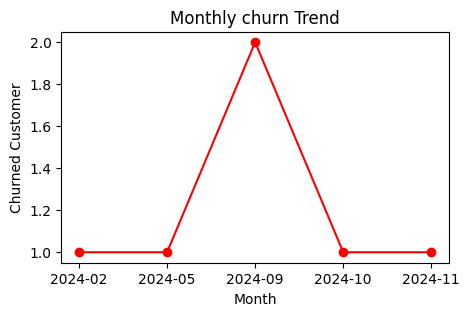

In [51]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(5,3))
plt.title('Monthly churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='red', marker='o')
plt.show()

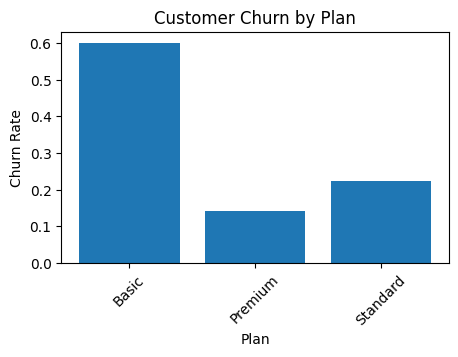

In [52]:
# Churn rate by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(5,3))
plt.bar(churn_plan.index, churn_plan.values)
plt.xlabel("Plan")
plt.ylabel("Churn Rate")
plt.title("Customer Churn by Plan")
plt.xticks(rotation=45)
plt.show()


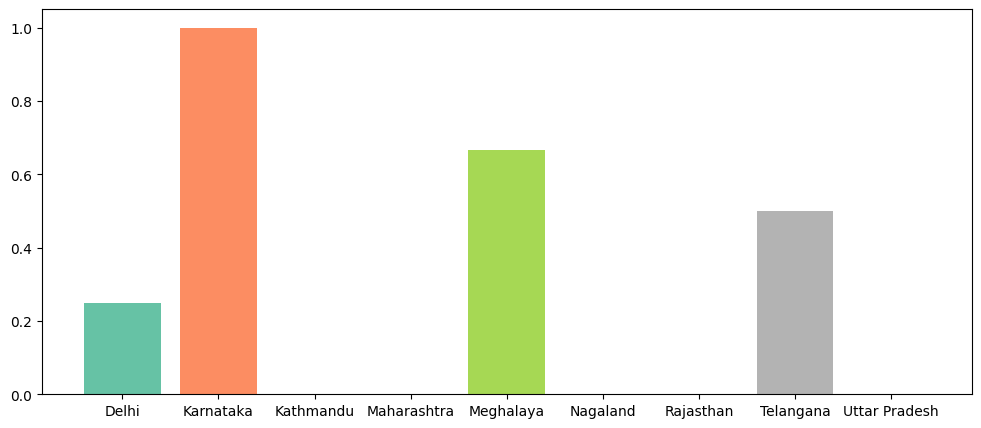

In [53]:
# churn by State
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.figure(figsize=(12,5))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

## Visulaization using Seaborn

In [54]:
# Heatmap (correlation matrix)
sns.heatmap(df_visual.corr(), annot=True)

ValueError: could not convert string to float: '0002-ORFBO'

In [55]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [56]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [57]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered=True).codes

C:\Users\Prince\AppData\Local\Temp\ipykernel_21972\1279709882.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered=True).codes
C:\Users\Prince\AppData\Local\Temp\ipykernel_21972\1279709882.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered=True).codes
C:\Users\Prince\AppData\Local\Temp\ipykernel_21972\1279709882.py:9

In [58]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

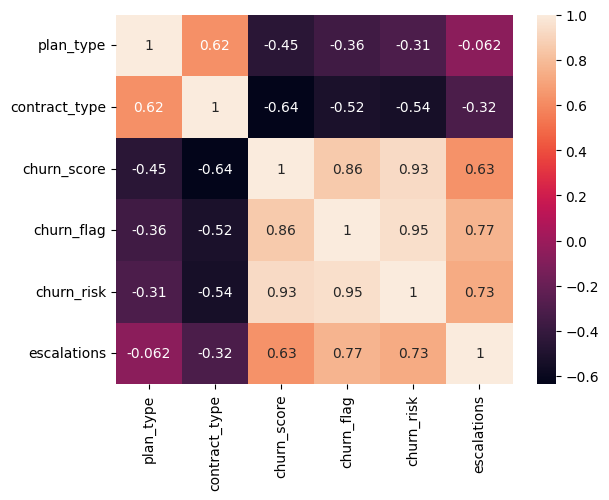

In [59]:
sns.heatmap(df_encoded.corr(), annot=True)

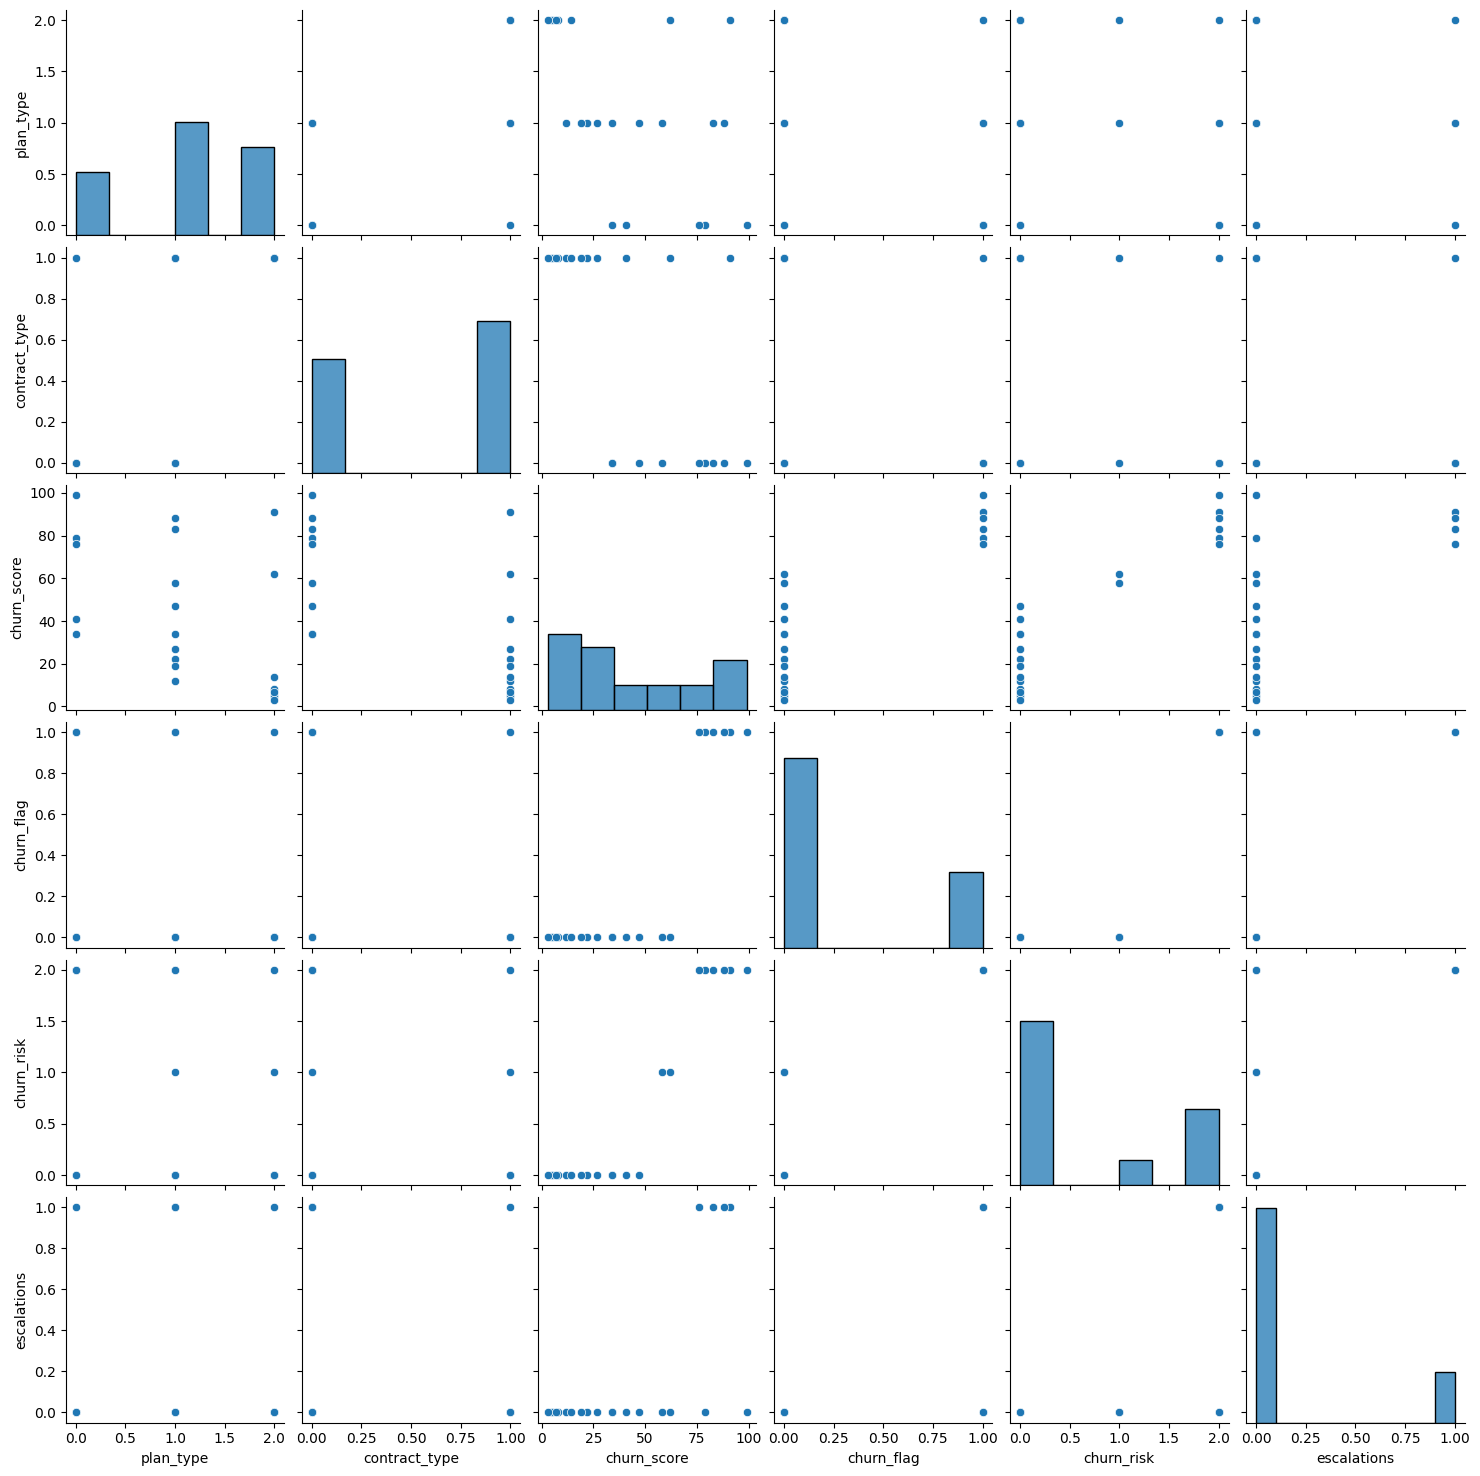

In [60]:
# pairplot-relationship between dataset

sns.pairplot(df_encoded)

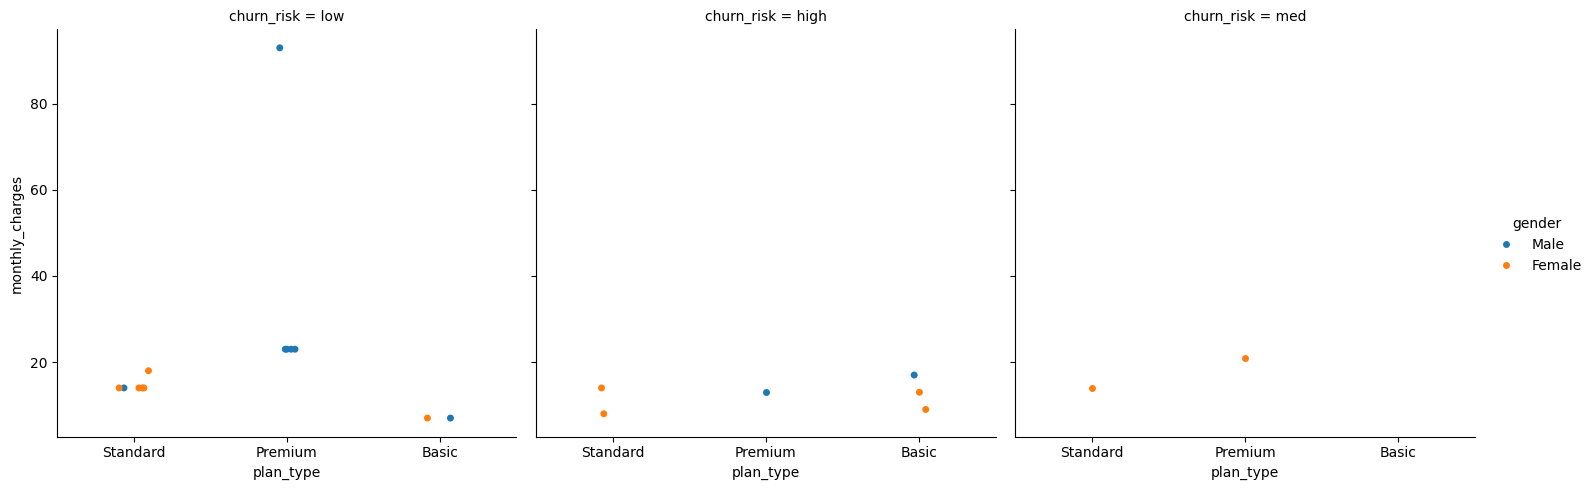

In [61]:
# Catplt/Facegrid plot - multi-dim comparison

sns.catplot(data = df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

## Pivot Table

In [63]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean').reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [64]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid' , 'churn_flag'],
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'})

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
